# 🔵 K-Means Clustering (التجميع)
**Day 3 — Core Algorithms**

---

So far, every algorithm we've used has been *supervised* — we always had correct labels to train on.

K-Means is our first **unsupervised** algorithm. There are no labels. The goal is to discover natural groups hidden in the data.

**How K-Means works:**
1. Randomly place K centroids (cluster centers) in the feature space
2. Assign each point to its nearest centroid
3. Move each centroid to the mean of all points assigned to it
4. Repeat steps 2–3 until the centroids stop moving

By the end, each point belongs to a cluster defined by the nearest centroid.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings; warnings.filterwarnings("ignore")

print("Ready ✓")

Ready ✓


## Part 1 — How K-Means Learns (Step by Step)

Let's watch K-Means converge on a simple 2D dataset.

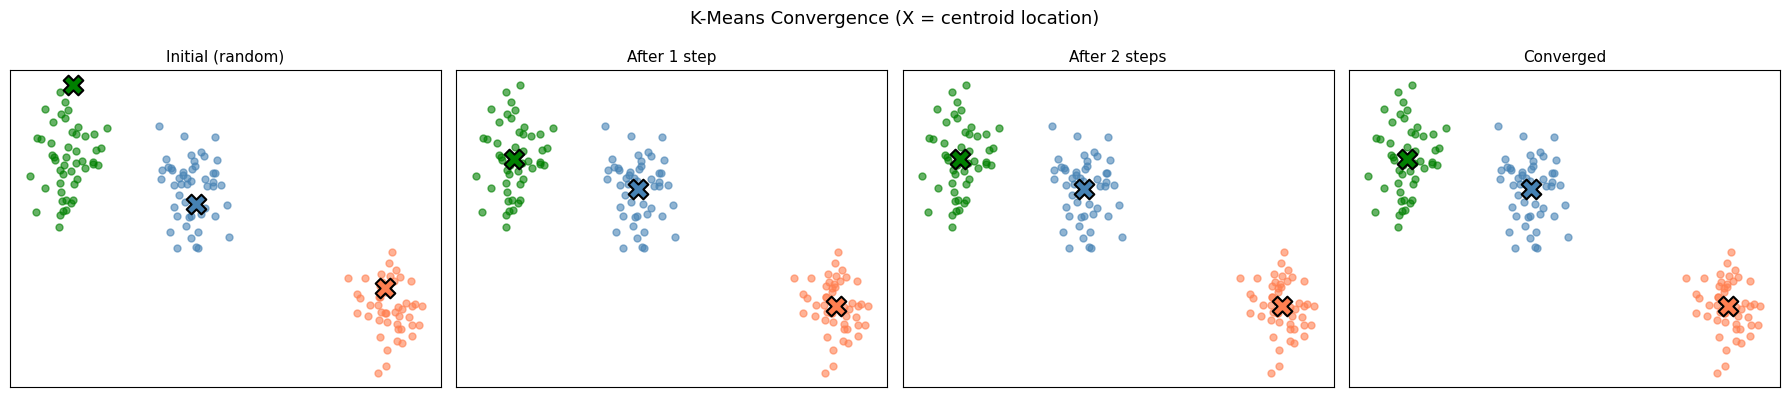

Notice how the X markers (centroids) move toward the center of each cluster over iterations.


In [2]:
# Generate 3-cluster data
X_demo, _ = make_blobs(n_samples=150, centers=3, cluster_std=1.0, random_state=7)

# Manually show 4 iterations of K-Means
np.random.seed(42)
init_centroids = X_demo[np.random.choice(len(X_demo), 3, replace=False)]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
iteration_titles = ["Initial (random)", "After 1 step", "After 2 steps", "Converged"]

centroids = init_centroids.copy()
for step, ax in enumerate(axes):
    # Assign
    dists = np.array([[np.linalg.norm(x - c) for c in centroids] for x in X_demo])
    labels = np.argmin(dists, axis=1)

    # Plot
    colors = ["steelblue", "coral", "green"]
    for k in range(3):
        mask = labels == k
        ax.scatter(X_demo[mask, 0], X_demo[mask, 1], c=colors[k], s=25, alpha=0.6)
        ax.scatter(*centroids[k], c=colors[k], s=200, marker="X", edgecolors="black", linewidths=1.5, zorder=5)

    ax.set_title(iteration_titles[step], fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])

    # Update centroids
    new_centroids = np.array([X_demo[labels == k].mean(axis=0) for k in range(3)])
    centroids = new_centroids

plt.suptitle("K-Means Convergence (X = centroid location)", fontsize=13)
plt.tight_layout(); plt.show()
print("Notice how the X markers (centroids) move toward the center of each cluster over iterations.")

## Part 2 — The Elbow Method: Choosing K

K-Means requires you to specify K (number of clusters) in advance. How do you choose the right K?

The **Elbow Method** plots the within-cluster inertia (sum of squared distances from each point to its centroid) for different values of K. You look for the "elbow" — the point where adding more clusters stops significantly improving the fit.

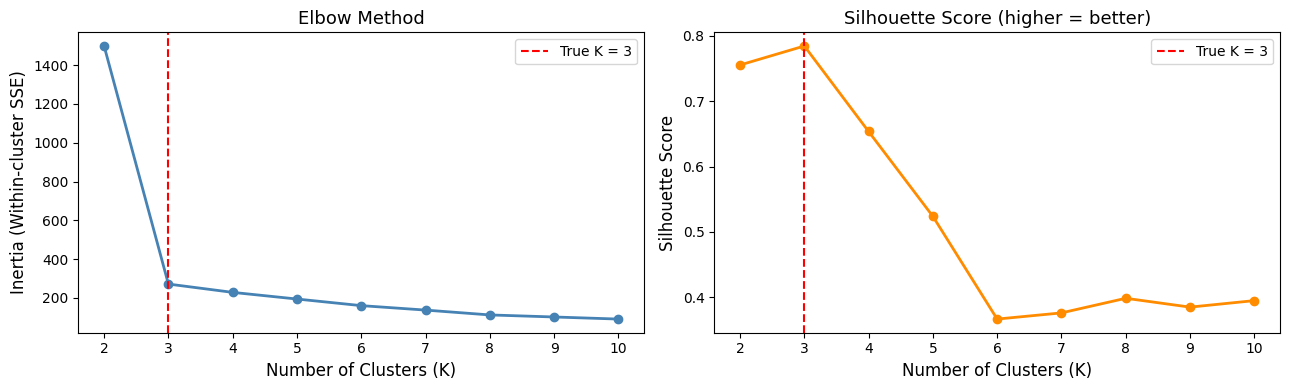

The elbow at K=3 and the silhouette peak at K=3 both confirm that 3 clusters is optimal.


In [3]:
# Compute inertia for K = 1 to 10
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_demo)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_demo, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Elbow plot
axes[0].plot(K_range, inertias, marker="o", color="steelblue", linewidth=2)
axes[0].axvline(3, color="red", linestyle="--", label="True K = 3")
axes[0].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[0].set_ylabel("Inertia (Within-cluster SSE)", fontsize=12)
axes[0].set_title("Elbow Method", fontsize=13)
axes[0].legend()

# Silhouette scores (another way to pick K)
axes[1].plot(K_range, silhouettes, marker="o", color="darkorange", linewidth=2)
axes[1].axvline(3, color="red", linestyle="--", label="True K = 3")
axes[1].set_xlabel("Number of Clusters (K)", fontsize=12)
axes[1].set_ylabel("Silhouette Score", fontsize=12)
axes[1].set_title("Silhouette Score (higher = better)", fontsize=13)
axes[1].legend()

plt.tight_layout(); plt.show()
print("The elbow at K=3 and the silhouette peak at K=3 both confirm that 3 clusters is optimal.")

## Part 3 — Real Application: Customer Segmentation

Segment customers of an e-commerce site into groups based on their purchase behavior.
This is one of the most common real-world uses of K-Means.

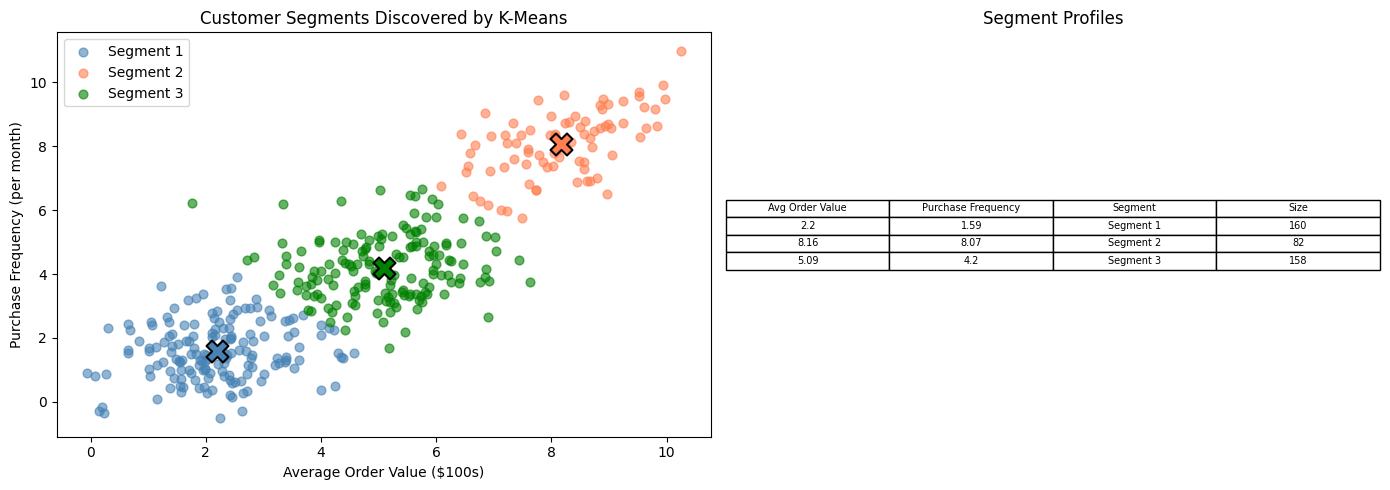

Segment 1 (160 customers): likely 'Casual Browsers'
  Avg order value: 2.2 ($100s),  frequency: 1.6/month
Segment 2 (82 customers): likely 'VIP Customers'
  Avg order value: 8.2 ($100s),  frequency: 8.1/month
Segment 3 (158 customers): likely 'Regular Customers'
  Avg order value: 5.1 ($100s),  frequency: 4.2/month


In [4]:
# Simulate customer purchase behavior
np.random.seed(42)
n = 400

# Three types of customers:
# Group A: High value, frequent (VIP customers)
# Group B: Medium value, occasional (regular customers)
# Group C: Low value, rare (casual browsers)
X_customers = np.vstack([
    np.random.multivariate_normal([8, 8],  [[1.2, 0.8], [0.8, 1.2]],  80),   # VIP
    np.random.multivariate_normal([5, 4],  [[1.5, 0.5], [0.5, 1.5]], 180),   # Regular
    np.random.multivariate_normal([2, 1.5],[[0.8, 0.2], [0.2, 0.8]], 140),   # Casual
])
feature_names = ["Average Order Value ($100s)", "Purchase Frequency (per month)"]

# Apply K-Means
km_customers = KMeans(n_clusters=3, random_state=42, n_init=10)
segment_labels = km_customers.fit_predict(X_customers)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
segment_colors = {0: "steelblue", 1: "coral", 2: "green"}
segment_names  = {}

for k in range(3):
    mask = segment_labels == k
    axes[0].scatter(X_customers[mask, 0], X_customers[mask, 1],
                    c=segment_colors[k], s=40, alpha=0.6, label=f"Segment {k+1}")
    axes[0].scatter(*km_customers.cluster_centers_[k], c=segment_colors[k],
                    s=250, marker="X", edgecolors="black", linewidths=1.5, zorder=5)

axes[0].set_xlabel(feature_names[0]); axes[0].set_ylabel(feature_names[1])
axes[0].set_title("Customer Segments Discovered by K-Means", fontsize=12)
axes[0].legend()

# Segment profiles
centers = pd.DataFrame(km_customers.cluster_centers_,
                        columns=["Avg Order Value", "Purchase Frequency"])
centers["Segment"] = [f"Segment {i+1}" for i in range(3)]
centers["Size"] = [np.sum(segment_labels==k) for k in range(3)]

axes[1].table(cellText=centers.round(2).values, colLabels=centers.columns,
              loc="center", cellLoc="center")
axes[1].axis("off")
axes[1].set_title("Segment Profiles", fontsize=12)

plt.tight_layout(); plt.show()

# Label the segments based on their profiles
for i, row in centers.iterrows():
    if row["Avg Order Value"] > 6:
        label = "VIP Customers"
    elif row["Avg Order Value"] > 4:
        label = "Regular Customers"
    else:
        label = "Casual Browsers"
    print(f"Segment {i+1} ({row['Size']} customers): likely '{label}'")
    print(f"  Avg order value: {row['Avg Order Value']:.1f} ($100s),  frequency: {row['Purchase Frequency']:.1f}/month")

---
## ✋ Exercise — Find Natural Groups in a New Dataset

Mall customers dataset: (200, 2)
       annual_income_k  spending_score
count            200.0           200.0
mean              60.7            45.9
std               24.4            24.4
min                6.7           -16.2
25%               45.4            28.1
50%               61.1            44.8
75%               78.9            66.6
max              109.8           107.2

Visualize first, then apply K-Means with K=3


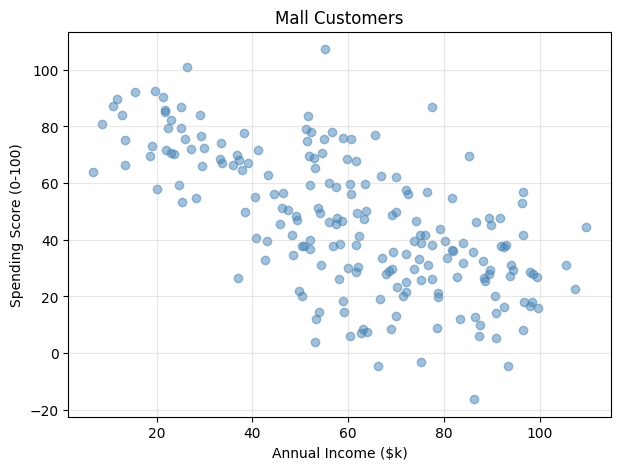

In [5]:
# Mall customer dataset (simplified)
np.random.seed(7)
n_mall = 200
mall = pd.DataFrame({
    "annual_income_k":  np.concatenate([
        np.random.normal(25, 8, 40),   # Low income
        np.random.normal(55, 10, 80),  # Middle income
        np.random.normal(85, 12, 80),  # High income
    ]),
    "spending_score": np.concatenate([
        np.random.normal(75, 15, 40),  # Low income but high spenders (?)
        np.random.normal(50, 20, 80),  # Middle of everything
        np.random.normal(30, 15, 80),  # High income, conservative spenders
    ]),
})

print("Mall customers dataset:", mall.shape)
print(mall.describe().round(1))
print()
print("Visualize first, then apply K-Means with K=3")

plt.figure(figsize=(7, 5))
plt.scatter(mall["annual_income_k"], mall["spending_score"], alpha=0.5, color="steelblue")
plt.xlabel("Annual Income ($k)"); plt.ylabel("Spending Score (0-100)")
plt.title("Mall Customers"); plt.grid(alpha=0.3); plt.show()

In [6]:
# TASK 1: Apply K-Means with K=3 to the mall dataset
# TASK 2: Plot the clusters with different colors
# TASK 3: Print the centroid coordinates and interpret what each segment represents
# YOUR CODE HERE:

print("Think about: do the discovered segments make business sense?")
print("What marketing strategy would you recommend for each segment?")

Think about: do the discovered segments make business sense?
What marketing strategy would you recommend for each segment?


### Exercises

**Try it yourself:**

1. **Parameter tuning**: Change the number of clusters `k` to different values (e.g., 2, 4, 10). How do the cluster centers shift and what happens to the inertia?
2. **Feature selection**: What happens if you run K-Means on only a subset of the available features? Do the resulting clusters still look meaningful on a 2D scatter plot?

### Offline Activity

**Independent practice:**
Load a new generic dataset (like `load_iris` from `sklearn.datasets`), purposefully drop the `target` labels so you only have unlabeled features, and try applying K-Means. Compare your final clusters to the true labels to see if the algorithm found the natural groupings organically!